# Ejercicio Formativo 1 Capitulo 2

## Importando librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

## 3. Cargar datos

"Cargue el conjunto de datos utilizando Pandas e imprima su contenido. Comente acerca del formato
utilizado para los datos."

Funciones

*   `read_csv`: permite leer un archivo csv y lo convierte en un DataFrame.
*   `head`: perimte visualizar las **n** primeras filas de un DataFrame (las primeras 5 por default).
*   `display`: permite mostrar un DataFrame en un formato más amigable.
*   `dtype`: devuelve el tipo de dato de cada columna de un DataFrame.








In [2]:
df = pd.read_csv("E1_data.csv")
display(df.head(10))

,X,Y,Set
0,8,6.58,A
1,8,5.76,A
2,8,7.71,A
3,8,8.84,A
4,8,8.47,A
5,8,7.04,A
6,8,5.25,A
7,19,12.50,A
8,8,5.56,A
9,8,7.91,A


In [3]:
df.dtypes

,0
X,int64
Y,float64
Set,object


## 4. Calcular métricas

"Calcule algunas métricas interesantes para obtener mayor conocimiento de estos datos. Es importante
notar que se esperan los valores de las métricas por conjunto, es decir, debe obtener las métricas para
el conjunto A, B, C y D de manera separada. Considere inicialmente las siguientes:
* Media.
* Desviación estándar.
* Máximo.
* Mínimo.
* Correlación entre las variables x e y.
* Kurtosis."

Funcion `groupby` agrupa los datos de un DataFrame, se utiliza la siguiente sintaxis:

```python
DataFrame.groupby(by=None, axis=0, level=None, as_index=True, sort=True, group_keys=True, squeeze=False, observed=False, dropna=True)
```

Donde:

*  `by` es la columna o columnas por las que se agruparán los datos. También puede ser una función o un diccionario.
*  `axis` es el eje a lo largo del cual se agruparán los datos. Por defecto es 0, lo que significa que se agruparán por filas. Si se establece en 1, se agruparán por columnas.
*  `level` es el nivel de jerarquía en el que se agruparán los datos.
as_index es un booleano que indica si se debe devolver un DataFrame con el índice de grupo como índice o no.
*  `sort` es un booleano que indica si se deben ordenar los grupos.
*  `group_keys` es un booleano que indica si se deben mostrar las claves de grupo.
*  `squeeze` es un booleano que indica si se debe devolver un DataFrame con una sola columna si es posible.
*  `observed` es un booleano que indica si se deben mostrar todas las categorías, incluso si no están presentes en los datos.
*  `dropna` es un booleano que indica si se deben eliminar las filas con valores nulos

In [4]:
df_agrupado = df.groupby("Set")
df_agrupado.head()

,X,Y,Set
0,8,6.58,A
1,8,5.76,A
2,8,7.71,A
3,8,8.84,A
4,8,8.47,A
11,10,9.14,B
12,8,8.14,B
13,13,8.74,B
14,9,8.77,B
15,11,9.26,B


In [5]:
print(df_agrupado)

Como se puede ver al hacer `group_by` se obtiene un objeto de tipo `DataFrameGroupBy`, que es un objeto que contiene información sobre los grupos y permite realizar operaciones sobre ellos.

Una función que se puede utilizar con un objeto `DataFrameGroupBy` es `groups`, que devuelve un diccionario con las claves de grupo y los índices de las filas que pertenecen a cada grupo.

In [6]:
print(df_agrupado.groups)

{'A': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'B': [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21], 'C': [22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32], 'D': [33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43]}


Otra función que se puede utilizar con un objeto `DataFrameGroupBy` es `get_group`, que permite obtener un grupo específico.

In [7]:
print(display(df_agrupado.get_group('A')))

,X,Y,Set
0,8,6.58,A
1,8,5.76,A
2,8,7.71,A
3,8,8.84,A
4,8,8.47,A
5,8,7.04,A
6,8,5.25,A
7,19,12.50,A
8,8,5.56,A
9,8,7.91,A


None


También se debe tener en cuenta que un objeto `DataFrameGroupBy` es posible acceder a las columnas del DataFrame original, lo que permite realizar operaciones sobre ellas. La diferencia es que las operaciones se realizarán sobre cada grupo en lugar de sobre todo el DataFrame. Se utiliza la misma sintaxys que en un Dataframe normal.

Funcion `describe`: devuelve información estadística de los datos del dataframe.

In [8]:
df.describe()

,X,Y
count,44.000000,44.000000
mean,9.000000,7.500682
std,3.198837,1.958925
min,4.000000,3.100000
25%,7.000000,6.117500
50%,8.000000,7.520000
75%,11.000000,8.747500
max,19.000000,12.740000


In [9]:
df_agrupado.describe()

X                                               Y                      \
    count mean       std  min  25%  50%   75%   max count      mean       std   
Set                                                                             
A    11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909  2.030579   
B    11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909  2.031657   
C    11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000  2.030424   
D    11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909  2.031568   

                                     
      min    25%   50%   75%    max  
Set                                  
A    5.25  6.170  7.04  8.19  12.50  
B    3.10  6.695  8.14  8.95   9.26  
C    5.39  6.250  7.11  7.98  12.74  
D    4.26  6.315  7.58  8.57  10.84

Otras funciones

*   `mean`: calcula el promedio.
*   `str`: calcula la desviación estandar.
*   `min`: calcula el minimo valor.
*   `max`: calucla el maximo valor.








In [10]:
df_agrupado.corr()

X         Y
Set                      
A   X  1.000000  0.816521
    Y  0.816521  1.000000
B   X  1.000000  0.816237
    Y  0.816237  1.000000
C   X  1.000000  0.816287
    Y  0.816287  1.000000
D   X  1.000000  0.816421
    Y  0.816421  1.000000

In [11]:
for name, group in df.groupby('Set'):
    print(f"La curtosis de {name} para X es: {group['X'].kurtosis()}")
    print(f"La curtosis de {name} para Y es: {group['Y'].kurtosis()}")

La curtosis de A para X es: 11.0
La curtosis de A para Y es: 3.151314922962853
La curtosis de B para X es: -1.2000000000000002
La curtosis de B para Y es: 0.8461232328218724
La curtosis de C para X es: -1.2000000000000002
La curtosis de C para Y es: 4.384088613065109
La curtosis de D para X es: -1.2000000000000002
La curtosis de D para Y es: -0.534897734372739


## 5. Comente los resultados

## 6. Generar graficos

"Identifique aquellas métricas que son iguales para los conjuntos. Luego, visualice los conjuntos para
caracterizar de mejor manera sus diferencias. Para esto, genere cuatro gráficos de dispersión (scatter
plots, uno por conjunto), donde se evidencie la relación (x, y) de los pares que corresponden a cada
uno."

De la `Parte 4` se obtuvo lo siguiente:

- Para los datos de `X` se obtuvo que la media y la desviación estándar son las mismas para cada grupo. Respecto al mínimo, el máximo y la curtosis son los mismos pero solo para los grupos `B`, `C` y `D`.

- Para los datos de `Y` se obtuvo que la media y la desviación estándar son las mismas para cada grupo con algunas diferencias en los decimales. Respecto al mínimo, el máximo y la curtosis dieron resultados distinto para cada grupo.

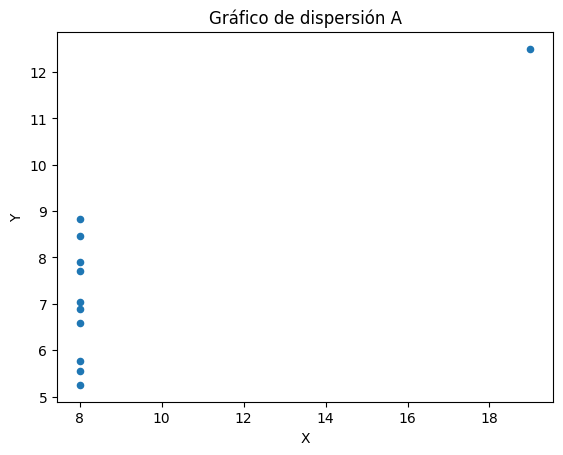

In [12]:
df_agrupado.get_group('A').plot.scatter(x='X', y='Y', title="Gráfico de dispersión A")
plt.show()

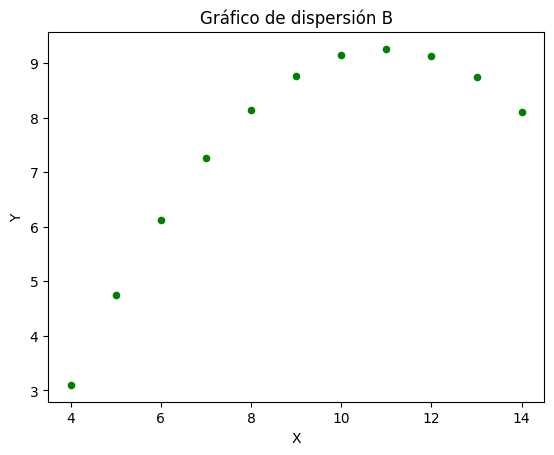

In [13]:
df_agrupado.get_group('B').plot.scatter(x='X', y='Y', c='green', title="Gráfico de dispersión B")
plt.show()

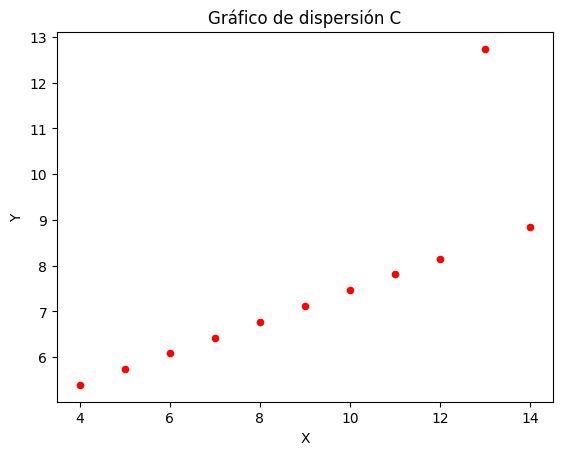

In [14]:
df_agrupado.get_group('C').plot.scatter(x='X', y='Y', c='red', title="Gráfico de dispersión C")
plt.show()

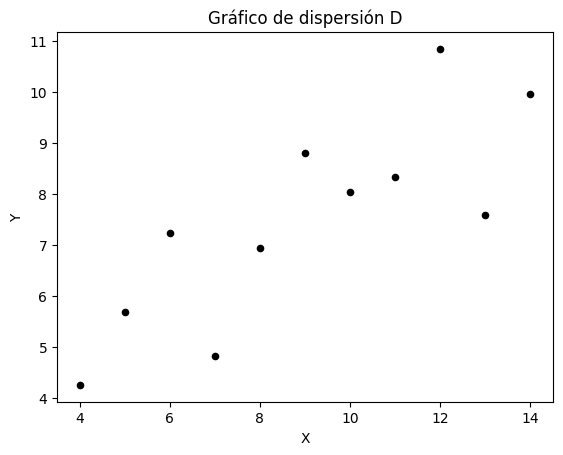

In [15]:
df_agrupado.get_group('D').plot.scatter(x='X', y='Y', c='black', title="Gráfico de dispersión D")
plt.show()

# 7. Descartar datos

"Repita los pasos anteriores, esta vez descartando aleatoriamente el 10% de los datos de cada conjunto,
e imputando sus valores utilizando la media de cada coordenada. Comente sobre las diferencias en los
resultados"

In [16]:
def redefiniendo_dataframe(df):
    # Paso 1
    datos_nuevo_df = []
    # Paso 2
    for nombre, grupo in df.groupby('Set'):
        print(f"Los indices de las filas del grupo {nombre} son: {grupo.index}")
        # Paso 3
        num_filas_eliminar = int(len(grupo) * 0.1)
        # Paso 4
        filas_eliminar = np.random.choice(grupo.index, num_filas_eliminar)
        # Paso 5
        grupo = grupo.drop(filas_eliminar)
        print(f"Se eliminaron {num_filas_eliminar} filas de {nombre}")
        print(f"Las filas eliminadas fueron: {filas_eliminar}")
        # Paso 6
        x_media = group['X'].mean()
        y_media = group['Y'].mean()
        # Paso 7
        nuevas_filas = pd.DataFrame({
            "Set": [nombre] * num_filas_eliminar,
            "X": [x_media] * num_filas_eliminar,
            "Y": [y_media] * num_filas_eliminar
        })
        # Paso 8
        grupo = pd.concat([grupo, nuevas_filas])
        # Paso 9
        datos_nuevo_df.append(grupo)
    # Paso 10
    return pd.concat(datos_nuevo_df)


In [17]:
nuevo_df = redefiniendo_dataframe(df)

Los indices de las filas del grupo A son: Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype='int64')
Se eliminaron 1 filas de A
Las filas eliminadas fueron: [9]
Los indices de las filas del grupo B son: Index([11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21], dtype='int64')
Se eliminaron 1 filas de B
Las filas eliminadas fueron: [19]
Los indices de las filas del grupo C son: Index([22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32], dtype='int64')
Se eliminaron 1 filas de C
Las filas eliminadas fueron: [31]
Los indices de las filas del grupo D son: Index([33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43], dtype='int64')
Se eliminaron 1 filas de D
Las filas eliminadas fueron: [39]


In [18]:
nuevo_df.groupby("Set").describe()

X                                                    Y            \
    count      mean       std  min  25%  50%   75%   max count      mean   
Set                                                                        
A    11.0  9.090909  3.300138  8.0  8.0  8.0   8.0  19.0  11.0  7.463719   
B    11.0  8.727273  3.165151  4.0  6.5  9.0  10.5  14.0  11.0  7.352810   
C    11.0  9.181818  3.250175  4.0  7.0  9.0  11.5  14.0  11.0  7.598264   
D    11.0  9.272727  3.165151  4.0  7.5  9.0  11.5  14.0  11.0  7.524628   

                                                
          std   min    25%   50%    75%    max  
Set                                             
A    2.026078  5.25  6.170  7.04  8.090  12.50  
B    1.959109  3.10  6.695  8.10  8.755   9.26  
C    1.998839  5.39  6.425  7.46  7.980  12.74  
D    2.029740  4.26  6.315  7.58  8.570  10.84

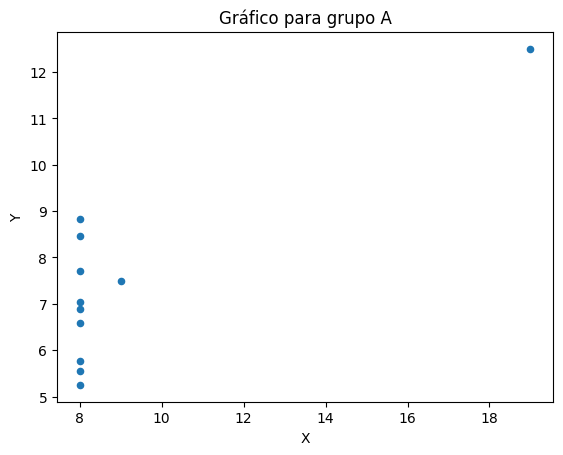

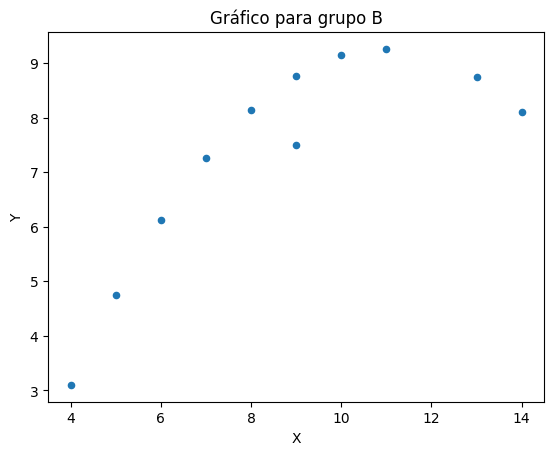

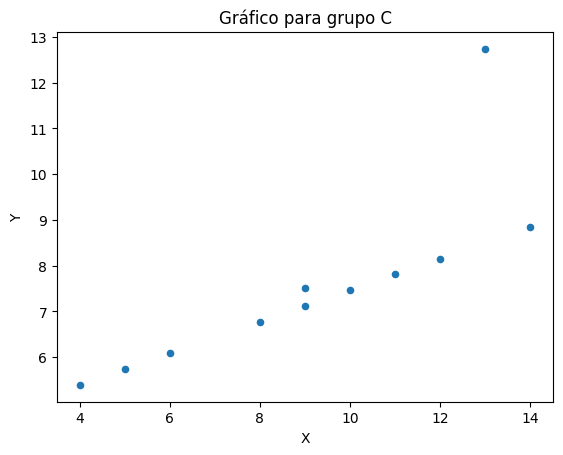

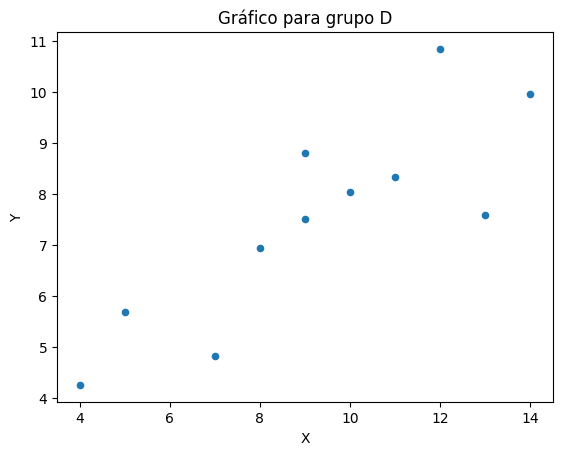

In [19]:
for name, group in nuevo_df.groupby('Set'):
    group.plot.scatter(x='X', y='Y', title=f"Gráfico para grupo {name}")